# Анализ тональности русскоязычных текстов
## Наивный байесовский классификатор

**Цель:** построить модель классификации текстовых отзывов на три класса тональности (нейтральный / положительный / отрицательный) с использованием алгоритма наивного Байеса.

**Датасет:** [Russian Sentiment Dataset](https://www.kaggle.com/datasets/aadimator/russian-sentiment-dataset) (~290 тыс. записей)

## 1. Краткая теория

**Наивный байесовский классификатор** основан на теореме Байеса с допущением условной независимости признаков: P(y|x) ∝ P(y) · ∏P(xᵢ|y). В данной работе используется MultinomialNB с TF-IDF векторизацией для классификации тональности текстов. Подробная теория — в [README.md](README.md).

## 2. Загрузка данных

In [1]:
!pip install -q pymorphy3

In [2]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

import pymorphy3

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

### Загрузка датасета

Загружаем датасет через kagglehub.

In [3]:
import kagglehub
import os

path = kagglehub.dataset_download("mar1mba/russian-sentiment-dataset")
csv_filename = os.path.join(path, "sentiment_dataset.csv")
print(f"Файл: {csv_filename}")

Файл: C:\Users\danii\.cache\kagglehub\datasets\mar1mba\russian-sentiment-dataset\versions\2\sentiment_dataset.csv


In [4]:
df = pd.read_csv(csv_filename)
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер датасета: 290458 строк, 3 столбцов


,text,label,src
0,"Пальто красивое, но пришло с дырой в молнии. П...",0,rureviews
1,"Очень долго шел заказ,ждала к новому году,приш...",0,rureviews
2,"Могу сказать одно, брюки нормальные, НО они бы...",0,rureviews
3,"Доставка быстрая, меньше месяца. Заказывали ра...",0,rureviews
4,Мне не очень понравилось это платье. Размер ...,0,rureviews


## 3. Первичный анализ

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290458 entries, 0 to 290457
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    290458 non-null  object
 1   label   290458 non-null  int64 
 2   src     290458 non-null  object
dtypes: int64(1), object(2)
memory usage: 6.6+ MB


In [6]:
# проверим пропуски
print('Пропуски по столбцам:')
print(df.isnull().sum())
print()
print('Дубликаты:', df.duplicated(subset='text').sum())

Пропуски по столбцам:
text     0
label    0
src      0
dtype: int64

Дубликаты: 68


In [7]:
# уберём дубликаты если есть
before = len(df)
df = df.drop_duplicates(subset='text').reset_index(drop=True)
print(f'Удалено дубликатов: {before - len(df)}')
print(f'Осталось строк: {len(df)}')

Удалено дубликатов: 68
Осталось строк: 290390


In [8]:
df.describe()

,label
count,290390.000000
mean,1.001381
std,0.816353
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,2.000000


In [9]:
# маппинг для удобства
label_names = {0: 'Нейтральный', 1: 'Положительный', 2: 'Отрицательный'}
df['sentiment'] = df['label'].map(label_names)

print('Распределение классов:')
print(df['label'].value_counts().sort_index())

Распределение классов:
label
0    96562
1    96865
2    96963
Name: count, dtype: int64


### Анализ баланса

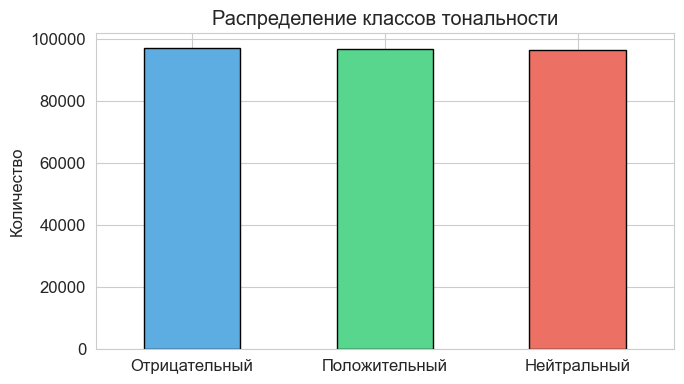

In [10]:
# распределение классов
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#5dade2', '#58d68d', '#ec7063']
df['sentiment'].value_counts().plot.bar(ax=ax, color=colors, edgecolor='black')
ax.set_title('Распределение классов тональности')
ax.set_ylabel('Количество')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

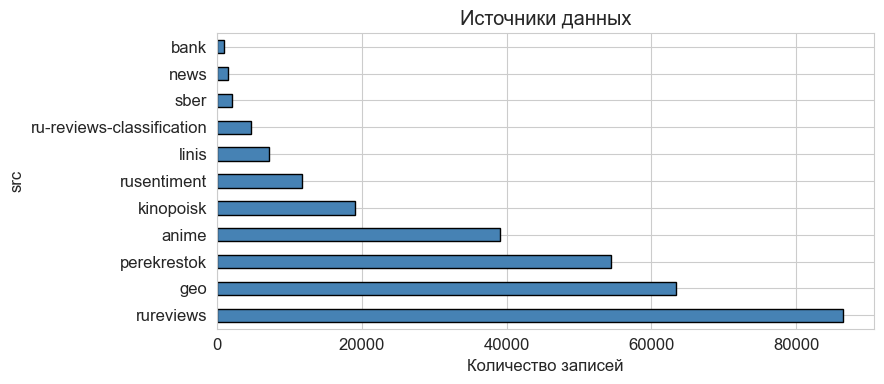

In [11]:
# посмотрим на источники данных
fig, ax = plt.subplots(figsize=(9, 4))
df['src'].value_counts().plot.barh(ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Источники данных')
ax.set_xlabel('Количество записей')
plt.tight_layout()
plt.show()

In [12]:
# добавим длину текста в символах и количество слов
df['text_len'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

print('Статистика по длине текста (символы):')
print(df.groupby('sentiment')['text_len'].describe().round(1))
print()
print('Статистика по количеству слов:')
print(df.groupby('sentiment')['word_count'].describe().round(1))

Статистика по длине текста (символы):
                 count   mean    std  min   25%    50%    75%     max
sentiment                                                            
Нейтральный    96562.0  338.6  369.2  1.0  70.0  176.0  484.0  1500.0
Отрицательный  96963.0  371.2  381.1  1.0  81.0  208.0  558.0  1500.0
Положительный  96865.0  310.0  360.8  1.0  66.0  153.0  398.0  1500.0

Статистика по количеству слов:
                 count  mean   std  min   25%   50%   75%    max
sentiment                                                       
Нейтральный    96562.0  51.2  55.6  1.0  11.0  27.0  74.0  277.0
Отрицательный  96963.0  56.6  58.0  1.0  12.0  32.0  85.0  279.0
Положительный  96865.0  45.7  54.2  0.0   9.0  22.0  59.0  261.0


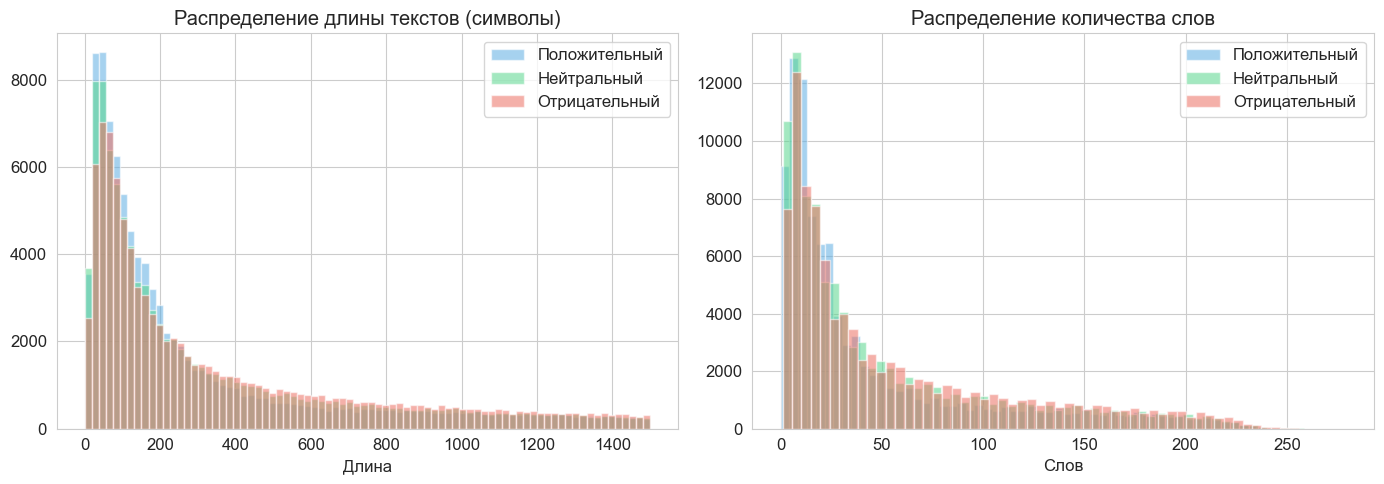

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sent, color in zip(['Положительный', 'Нейтральный', 'Отрицательный'], colors):
    subset = df[df['sentiment'] == sent]
    axes[0].hist(subset['text_len'], bins=80, alpha=0.55, label=sent, color=color)
    axes[1].hist(subset['word_count'], bins=60, alpha=0.55, label=sent, color=color)

axes[0].set_title('Распределение длины текстов (символы)')
axes[0].set_xlabel('Длина')
axes[0].legend()

axes[1].set_title('Распределение количества слов')
axes[1].set_xlabel('Слов')
axes[1].legend()

plt.tight_layout()
plt.show()

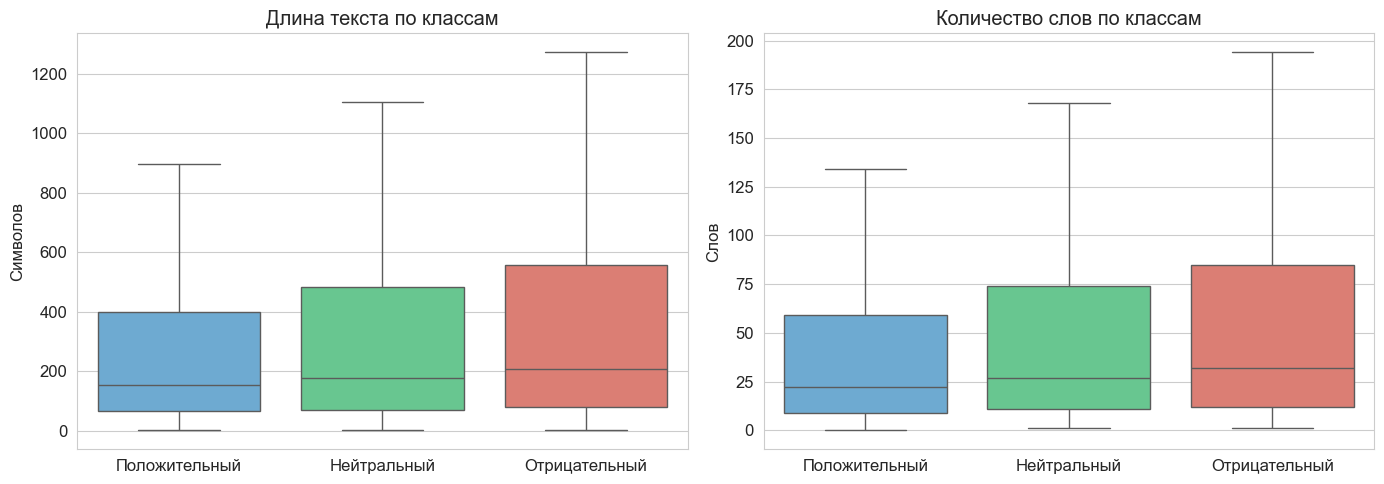

In [14]:
# boxplot для наглядности
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='sentiment', y='text_len', ax=axes[0],
            order=['Положительный','Нейтральный','Отрицательный'],
            palette=colors, showfliers=False)
axes[0].set_title('Длина текста по классам')
axes[0].set_xlabel('')
axes[0].set_ylabel('Символов')

sns.boxplot(data=df, x='sentiment', y='word_count', ax=axes[1],
            order=['Положительный','Нейтральный','Отрицательный'],
            palette=colors, showfliers=False)
axes[1].set_title('Количество слов по классам')
axes[1].set_xlabel('')
axes[1].set_ylabel('Слов')

plt.tight_layout()
plt.show()

In [15]:
# примеры текстов из каждого класса
for lbl in [0, 1, 2]:
    print(f'--- {label_names[lbl]} ---')
    samples = df[df['label'] == lbl]['text'].sample(3, random_state=42)
    for i, t in enumerate(samples, 1):
        print(f'  {i}. {t[:150]}')
    print()

--- Нейтральный ---
  1. Купила чёрные и фиолетовые, фиолетовые на рост 177 подошли впритык,  а чёрные только на дочь рост 140.
  2. ни укого случайно не сохранился номер от моей аськи старой??
  3. Аниме понравилось - красивые персонажи, неплохая музыка, отличные сэйюПоначалу сюжет может напомнить "серьёзный" детский фанфик в стиле: он и она - "н

--- Положительный ---
  1. качественные штаны. правда то ли супер высокая посадка толи низкая мотня. на рост 168см и 75-95 брала м. практически везде в обтяжку. для спортивного 
  2. Солдаты Красной армии, даже заживо сгорая, продолжали стрелять из полыхавших домов (из письма пехотного офицера 7-й танковой дивизии о боях в деревне 
  3. Соответствует описанию. XXL  идет на 50 размер . Трикотаж плотный, тянется хорошо

--- Отрицательный ---
  1. Шаурма ужасная, привкус тухлых или пропавших ингредиентов, шаурма разваливается в руках, вся течет, мало соуса, не рекомендую)\nПожалейте свой желудок
  2. Соус настолько жирный, что есть невозможно, 

## 4. Предобработка

Будем делать следующее:
- привести к нижнему регистру
- убрать пунктуацию и цифры
- удалить стоп-слова
- лемматизация с помощью pymorphy3

In [16]:
morph = pymorphy3.MorphAnalyzer()

# стоп-слова — частицу 'не' специально НЕ включаем,
# потому что она важна для тональности (не_понравиться != понравиться)
STOP_WORDS = set(
    'и в во что он на я с со как а то все она так его но да ты к у '
    'же вы за бы по только ее мне было вот от меня еще о из ему '
    'теперь когда даже ну вдруг ли если уже или быть был него до вас '
    'нибудь опять уж вам ведь там потом себя ей перед ней этот каждый '
    'можно мой сейчас чтобы чем раз при этом один тоже себе свой свою '
    'которые которая который которых которому моя тебя тебе бы ещё '
    'будет какой какая между через после для без чего'.split()
)

# частицы отрицания, которые будем склеивать со следующим словом
NEGATION_WORDS = {'не', 'ни', 'нет', 'нету', 'никак', 'ничуть', 'нисколько'}

punct_re = re.compile(r'[^\w\s]', re.UNICODE)
digit_re = re.compile(r'\d+')

def clean_text(text):
    text = str(text).lower()
    text = punct_re.sub(' ', text)
    text = digit_re.sub(' ', text)
    tokens = text.split()

    # склеиваем отрицание со следующим словом:
    # 'не' + 'понравилось' -> 'не_понравилось'
    merged = []
    i = 0
    while i < len(tokens):
        if tokens[i] in NEGATION_WORDS and i + 1 < len(tokens):
            merged.append(tokens[i] + '_' + tokens[i + 1])
            i += 2
        else:
            merged.append(tokens[i])
            i += 1

    # лемматизация + убираем стоп-слова и короткие токены
    lemmas = []
    for t in merged:
        if '_' in t:
            # для склеенных токенов: лемматизируем только вторую часть
            prefix, word = t.split('_', 1)
            lemma = prefix + '_' + morph.parse(word)[0].normal_form
            lemmas.append(lemma)
        else:
            if t in STOP_WORDS or len(t) < 2:
                continue
            lemma = morph.parse(t)[0].normal_form
            lemmas.append(lemma)
    return ' '.join(lemmas)

In [17]:
# проверим на паре примеров
test_texts = [
    'Отличный товар! Очень доволен покупкой.',
    'Товар не пришёл, мне не понравилось',
    'Ужасное качество, деньги на ветер...',
    'Нормально, ничего особенного.',
    'Не рекомендую, не стоит своих денег'
]
for t in test_texts:
    print(f'{t}  =>  {clean_text(t)}')

Отличный товар! Очень доволен покупкой.  =>  отличный товар очень довольный покупка
Товар не пришёл, мне не понравилось  =>  товар не_прийти не_понравиться
Ужасное качество, деньги на ветер...  =>  ужасный качество деньга ветер
Нормально, ничего особенного.  =>  нормально ничего особенный
Не рекомендую, не стоит своих денег  =>  не_рекомендовать не_стоить свой деньга


In [18]:
%%time
# лемматизация всего датасета — это самый долгий шаг, несколько минут
df['clean'] = df['text'].apply(clean_text)
print('Готово!')

Готово!
CPU times: total: 9min 5s
Wall time: 9min 7s


In [19]:
# посмотрим что получилось
df[['text', 'clean', 'sentiment']].sample(5, random_state=1)

,text,clean,sentiment
106298,"Два раза пытался просмотреть гиас, ну не захва...",два раз пытаться просмотреть гиас не_захватыва...,Положительный
44265,Спасибо за товар.Всё соответствует описанию.До...,спасибо товар всё соответствовать описание кал...,Положительный
62308,"Товар не пришёл , вернули деньги",товар не_прийти вернуть деньга,Отрицательный
25407,Заказ не получила. деньги не вернули.,заказ не_получить деньга не_вернуть,Нейтральный
108744,"Задолбали челики, которые говорят о каких-то т...",задолбать челик говорить какой штамп это это п...,Положительный


In [20]:
# проверим — нет ли пустых строк после очистки
empty_mask = df['clean'].str.strip() == ''
print(f'Пустых текстов после обработки: {empty_mask.sum()}')
if empty_mask.sum() > 0:
    df = df[~empty_mask].reset_index(drop=True)
    print(f'Строк после удаления: {len(df)}')

Пустых текстов после обработки: 165
Строк после удаления: 290225


### Разделение на обучающую и тестовую выборки

In [21]:
X = df['clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Обучающая выборка: {len(X_train)}')
print(f'Тестовая выборка:  {len(X_test)}')
print()
print('Проверим стратификацию:')
print(y_train.value_counts(normalize=True).sort_index().round(3))
print(y_test.value_counts(normalize=True).sort_index().round(3))

Обучающая выборка: 232180
Тестовая выборка:  58045

Проверим стратификацию:
label
0    0.332
1    0.334
2    0.334
Name: proportion, dtype: float64
label
0    0.332
1    0.334
2    0.334
Name: proportion, dtype: float64


### Векторизация (TF-IDF)

Используем TfidfVectorizer — он преобразует текст в числовые признаки, учитывая частоту слов и их важность в корпусе. Возьмём униграммы и биграммы.

In [22]:
tfidf = TfidfVectorizer(
    max_features=120000,
    ngram_range=(1, 2),
    sublinear_tf=True,  # сглаживает частоты (log)
    min_df=3,
    max_df=0.85
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'Размерность матрицы (train): {X_train_tfidf.shape}')
print(f'Размерность матрицы (test):  {X_test_tfidf.shape}')

Размерность матрицы (train): (232180, 120000)
Размерность матрицы (test):  (58045, 120000)


In [23]:
# для интереса — самые частотные признаки
feature_names = tfidf.get_feature_names_out()
mean_tfidf = X_train_tfidf.mean(axis=0).A1
top_idx = mean_tfidf.argsort()[-20:][::-1]

print('Топ-20 признаков по средней TF-IDF:')
for i in top_idx:
    print(f'  {feature_names[i]:25s} {mean_tfidf[i]:.5f}')

Топ-20 признаков по средней TF-IDF:
  очень                     0.01871
  это                       0.01504
  хороший                   0.01389
  размер                    0.01135
  качество                  0.01002
  они                       0.00919
  большой                   0.00897
  такой                     0.00896
  продавец                  0.00890
  деньга                    0.00852
  весь                      0.00847
  товар                     0.00842
  быть                      0.00780
  есть                      0.00776
  просто                    0.00717
  тот                       0.00698
  вкусный                   0.00687
  прийти                    0.00678
  отличный                  0.00677
  этот                      0.00677


## 5. Обучение модели

Обучаем классификатор **MultinomialNB** — классический вариант для текстовых данных.

In [24]:
# Multinomial Naive Bayes
mnb = MultinomialNB(alpha=0.3)
mnb.fit(X_train_tfidf, y_train)

y_pred_mnb = mnb.predict(X_test_tfidf)
y_proba_mnb = mnb.predict_proba(X_test_tfidf)

print('MultinomialNB — результаты на тестовой выборке:')
print(f'  Accuracy:  {accuracy_score(y_test, y_pred_mnb):.4f}')
print(f'  F1-macro:  {f1_score(y_test, y_pred_mnb, average="macro"):.4f}')
print(f'  F1-weighted: {f1_score(y_test, y_pred_mnb, average="weighted"):.4f}')

MultinomialNB — результаты на тестовой выборке:
  Accuracy:  0.6981
  F1-macro:  0.7003
  F1-weighted: 0.7004


## 6. Оценка качества

In [25]:
target_names = ['негативный', 'нейтральный', 'позитивный']

print(classification_report(y_test, y_pred_mnb, target_names=target_names))

              precision    recall  f1-score   support

  негативный       0.58      0.63      0.61     19297
 нейтральный       0.82      0.77      0.80     19362
  позитивный       0.71      0.68      0.70     19386

    accuracy                           0.70     58045
   macro avg       0.70      0.70      0.70     58045
weighted avg       0.70      0.70      0.70     58045



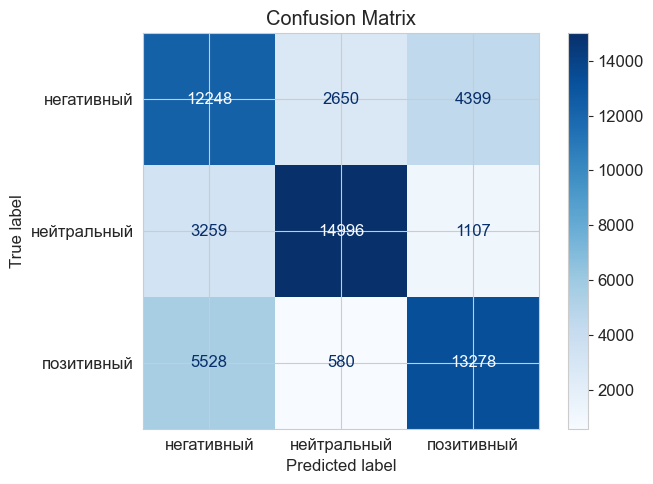

In [26]:
cm = confusion_matrix(y_test, y_pred_mnb)
disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

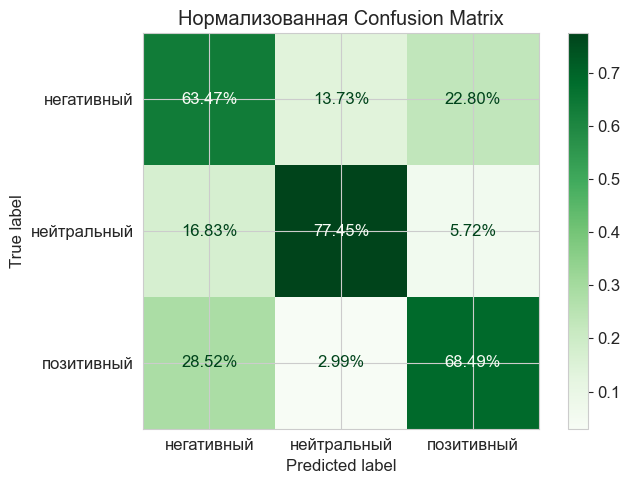

In [27]:
cm = confusion_matrix(y_test, y_pred_mnb, normalize='true')
disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Greens', values_format='.2%')
ax.set_title('Нормализованная Confusion Matrix')
plt.tight_layout()
plt.show()

In [28]:
# ROC-AUC (One-vs-Rest)
auc_mnb = roc_auc_score(y_test, y_proba_mnb, multi_class='ovr', average='macro')
print(f'ROC-AUC (macro, OvR): {auc_mnb:.4f}')

ROC-AUC (macro, OvR): 0.8661


In [29]:
# Сводка метрик
print(f'Accuracy:          {accuracy_score(y_test, y_pred_mnb):.4f}')
print(f'Precision (macro): {precision_score(y_test, y_pred_mnb, average="macro"):.4f}')
print(f'Recall (macro):    {recall_score(y_test, y_pred_mnb, average="macro"):.4f}')
print(f'F1 (macro):        {f1_score(y_test, y_pred_mnb, average="macro"):.4f}')
print(f'ROC-AUC (macro):   {auc_mnb:.4f}')

Accuracy:          0.6981
Precision (macro): 0.7040
Recall (macro):    0.6980
F1 (macro):        0.7003
ROC-AUC (macro):   0.8661


### Кросс-валидация

Проведём 5-фолдовую кросс-валидацию для оценки стабильности результатов.

In [30]:
# Кросс-валидация через Pipeline
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=120000, ngram_range=(1,2),
                              sublinear_tf=True, min_df=3, max_df=0.85)),
    ('clf', MultinomialNB(alpha=0.3))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [31]:
%%time
scores = cross_val_score(pipe, X, y, cv=skf, scoring='f1_macro', n_jobs=-1)

print(f'F1-macro по фолдам: {scores.round(4)}')
print(f'Среднее: {scores.mean():.4f} ± {scores.std():.4f}')

F1-macro по фолдам: [0.698  0.7031 0.6995 0.7045 0.7031]
Среднее: 0.7016 ± 0.0025
CPU times: total: 1.28 s
Wall time: 28.3 s


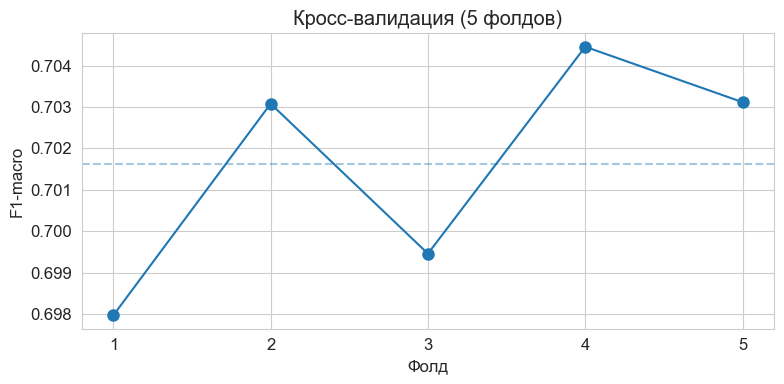

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
folds = np.arange(1, 6)
ax.plot(folds, scores, 'o-', markersize=8)
ax.axhline(scores.mean(), ls='--', alpha=0.4)
ax.set_xlabel('Фолд')
ax.set_ylabel('F1-macro')
ax.set_title('Кросс-валидация (5 фолдов)')
ax.set_xticks(folds)
plt.tight_layout()
plt.show()

### Анализ ошибок

Посмотрим, на каких текстах модель ошибается — это поможет понять слабые места.

In [33]:
# Используем обученную модель
best_model = mnb
best_preds = y_pred_mnb

In [34]:
# тексты где модель ошиблась
test_df = df.loc[X_test.index].copy()
test_df['predicted'] = best_preds
test_df['pred_label'] = test_df['predicted'].map(label_names)

errors = test_df[test_df['label'] != test_df['predicted']]
print(f'Всего ошибок: {len(errors)} из {len(test_df)} ({len(errors)/len(test_df)*100:.1f}%)')
print()

# распределение ошибок
print('Какие классы чаще путаются:')
error_pairs = errors.groupby(['sentiment', 'pred_label']).size().sort_values(ascending=False)
print(error_pairs.head(10))

Всего ошибок: 17523 из 58045 (30.2%)

Какие классы чаще путаются:
sentiment      pred_label   
Отрицательный  Нейтральный      5528
Нейтральный    Отрицательный    4399
Положительный  Нейтральный      3259
Нейтральный    Положительный    2650
Положительный  Отрицательный    1107
Отрицательный  Положительный     580
dtype: int64


In [35]:
# несколько примеров неправильных предсказаний
print('Примеры ошибок модели:')
print()
for _, row in errors.sample(8, random_state=42).iterrows():
    print(f'  Текст: {row["text"][:200]}')
    print(f'  Истинный: {row["sentiment"]}  |  Предсказано: {row["pred_label"]}')
    print()

Примеры ошибок модели:

  Текст: Когда-то парк был любимым местом отдыха горожан. Сейчас - это частная собственность, которая совершенно не нужна владельцу. Грязь, разруха, запустение; темные тропинки  наводят ужас на редких прохожих
  Истинный: Отрицательный  |  Предсказано: Нейтральный

  Текст: Во-первых, не надо связывать этот сериал с первоначальной "работой".  Тут только название и основное место сюжетной истории те же. Можно было бы переместить место действия в другой ресторан, назвать с
  Истинный: Положительный  |  Предсказано: Нейтральный

  Текст: спойлерТрудные подростки выхватывают лещей.Если в Крутом Учителе Онидзуке вам не хватало драк и "воспитательных моментов", то тут этот же автор идёт во все тяжкие. Чего стоит одна лишь концепция того,
  Истинный: Отрицательный  |  Предсказано: Нейтральный

  Текст: Сама площадка мне понравилась. Она разделена на зоны для детей разного возраста. Детям постарше можно полазить по веревкам, а детям помладше поиграть в пиратов на корабл

### Подбор alpha

Посмотрим, как зависит качество модели от параметра сглаживания alpha.

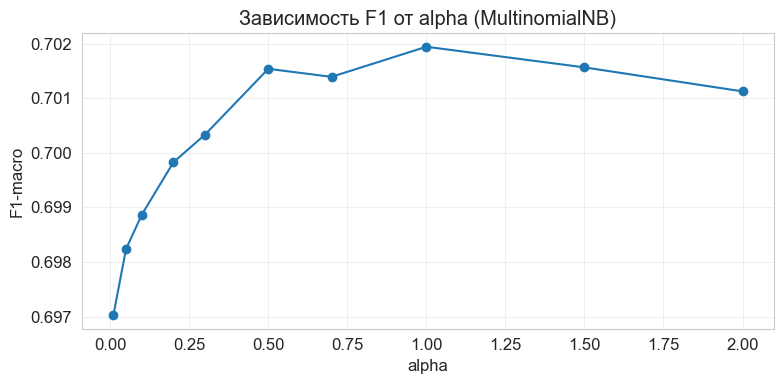

Лучший alpha = 1.0, F1 = 0.7019


In [36]:
alphas = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
f1_list = []

for a in alphas:
    m = MultinomialNB(alpha=a)
    m.fit(X_train_tfidf, y_train)
    f1_list.append(f1_score(y_test, m.predict(X_test_tfidf), average='macro'))

plt.figure(figsize=(8, 4))
plt.plot(alphas, f1_list, 'o-', markersize=6)
plt.xlabel('alpha')
plt.ylabel('F1-macro')
plt.title('Зависимость F1 от alpha (MultinomialNB)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_alpha = alphas[np.argmax(f1_list)]
print(f'Лучший alpha = {best_alpha}, F1 = {max(f1_list):.4f}')

### Проверка на своих примерах

In [37]:
def predict(text):
    """Предсказание тональности для произвольного текста."""
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    pred = best_model.predict(vec)[0]
    proba = best_model.predict_proba(vec)[0]
    print(f'Текст: {text}')
    print(f'Класс: {label_names[pred]}')
    print(f'Вероятности: ', end='')
    print(', '.join(f'{label_names[i]}: {p:.1%}' for i, p in enumerate(proba)))
    print()

In [38]:
predict('Отличный товар, буду заказывать ещё!')
predict('Полный отстой, выброшенные деньги')
predict('Средне. Ничего особенного, но и не плохо.')
predict('Доставка быстрая, но товар пришёл мятый')
predict('Хороший магазин, рекомендую друзьям')
predict('Не работает, верну обратно')

Текст: Отличный товар, буду заказывать ещё!
Класс: Положительный
Вероятности: Нейтральный: 3.0%, Положительный: 93.7%, Отрицательный: 3.3%

Текст: Полный отстой, выброшенные деньги
Класс: Отрицательный
Вероятности: Нейтральный: 3.0%, Положительный: 0.1%, Отрицательный: 96.9%

Текст: Средне. Ничего особенного, но и не плохо.
Класс: Нейтральный
Вероятности: Нейтральный: 83.2%, Положительный: 7.8%, Отрицательный: 9.0%

Текст: Доставка быстрая, но товар пришёл мятый
Класс: Положительный
Вероятности: Нейтральный: 40.7%, Положительный: 45.8%, Отрицательный: 13.4%

Текст: Хороший магазин, рекомендую друзьям
Класс: Положительный
Вероятности: Нейтральный: 3.3%, Положительный: 96.0%, Отрицательный: 0.7%

Текст: Не работает, верну обратно
Класс: Отрицательный
Вероятности: Нейтральный: 16.3%, Положительный: 1.8%, Отрицательный: 81.9%



### Выводы


В ходе работы была построена модель мультиклассовой классификации тональности отзывов на три класса (негативный, нейтральный, позитивный) с использованием MultinomialNB.

- Данные были предобработаны: лемматизация, удаление стоп-слов, векторизация TF-IDF.
- Обучена модель MultinomialNB.
- Проведена кросс-валидация и подбор гиперпараметра alpha.
- Проведён анализ ошибок и проверка модели на пользовательских примерах.